<a href="https://colab.research.google.com/github/JulianaMarqui1/Percepton/blob/main/Interface-Cerebro-PC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Projeto 2.

---

Interface Cérebro-Computador

##Etapa 01
*Download da base de dados.*



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt

os.listdir('/content/drive/MyDrive/Colab Notebooks/Projeto2/dataset_ssvep/data')
path = "/content/drive/MyDrive/Colab Notebooks/Projeto2/dataset_ssvep/data"
arquivos = os.listdir(path)

print(len(arquivos))

data = []

for name in sorted(os.listdir(path)):
    if name.endswith(".mat"):
        mat = loadmat(os.path.join(path, name))
        data.append(mat['data'])

data[0].shape


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
35


(64, 1500, 40, 6)

##Etapa 02

*Organização da matriz dos dados de entrada X e rótulos Y.*


In [ ]:
f1 = 0  # 8Hz
f2 = 2   # 10Hz

X = []
y = []

channel = 60  #eletrodo 61

for participants in data:

    for bloco in range(6): #f1

        trial = participants[channel, 125:1375, f1, bloco]

        X.append(trial)
        y.append(+1)

    for bloco in range(6): #f2

        trial = participants[channel, 125:1375, f2, bloco]

        X.append(trial)
        y.append(-1)

    break

X = np.array(X, dtype=np.float32)
y = np.array(y)

print(X.shape)
print(y.shape)

X_f1 = X[y == 1]
X_f2 = X[y == -1]


(12, 1250)
(12,)


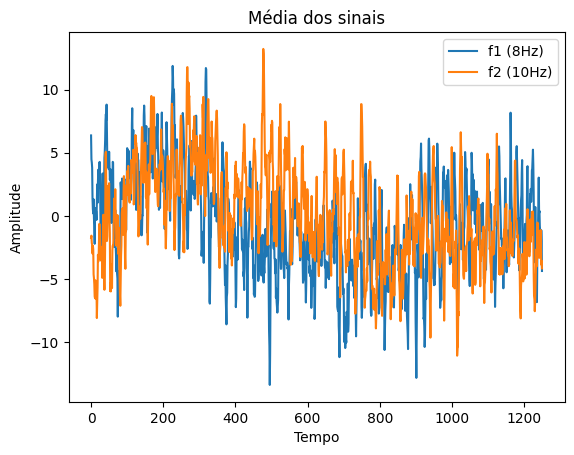

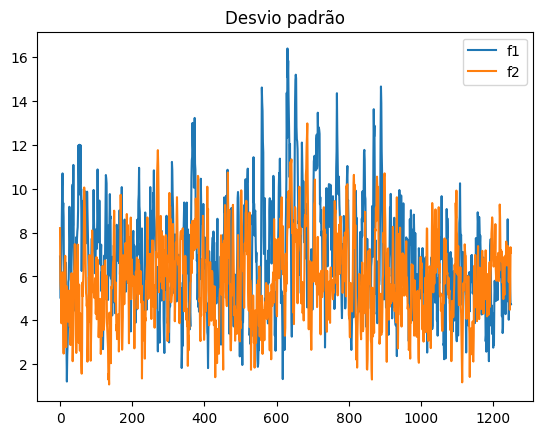

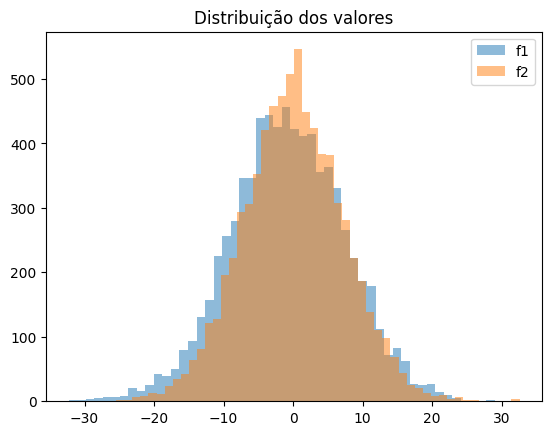

f1 (8Hz)
Média: -0.78860974
Desvio padrão: 8.25638
Máximo: 29.014118
Mínimo: -32.29356

f2 (10Hz) 
Média: 0.07889779
Desvio padrão: 7.2497935
Máximo: 32.569344
Mínimo: -25.44807


In [ ]:
#Conhecendo a base de dados - analise no tempo

#media
media_f1 = np.mean(X_f1, axis=0)
media_f2 = np.mean(X_f2, axis=0)

plt.figure()
plt.plot(media_f1, label='f1 (8Hz)')
plt.plot(media_f2, label='f2 (10Hz)')
plt.legend()
plt.title("Média dos sinais")
plt.xlabel("Tempo")
plt.ylabel("Amplitude")
plt.show()

#desvio padrão
std_f1 = np.std(X_f1, axis=0)
std_f2 = np.std(X_f2, axis=0)

plt.figure()
plt.plot(std_f1, label='f1')
plt.plot(std_f2, label='f2')
plt.legend()
plt.title("Desvio padrão")
plt.show()

#histogramas
plt.figure()
plt.hist(X_f1.flatten(), bins=50, alpha=0.5, label='f1')
plt.hist(X_f2.flatten(), bins=50, alpha=0.5, label='f2')
plt.legend()
plt.title("Distribuição dos valores")
plt.show()

print("f1 (8Hz)")
print("Média:", np.mean(X_f1))
print("Desvio padrão:", np.std(X_f1))
print("Máximo:", np.max(X_f1))
print("Mínimo:", np.min(X_f1))

print("\nf2 (10Hz) ")
print("Média:", np.mean(X_f2))
print("Desvio padrão:", np.std(X_f2))
print("Máximo:", np.max(X_f2))
print("Mínimo:", np.min(X_f2))

Análise temporal da média ajuda a entender como a cérebro reage aos estímulos.

##Etapa 03

*Implementar o perceptron que receba em sua entrada a matriz de dados X e retorne o valor de Y.*

In [ ]:
#Partição dos dados:4 treinamento e  validação.
np.random.shuffle(X_f1)
np.random.shuffle(X_f2)
# treino
X_train = np.vstack((X_f1[:4], X_f2[:4]))
y_train = np.array([1]*4 + [-1]*4)

# teste
X_test = np.vstack((X_f1[4:], X_f2[4:]))
y_test = np.array([1]*2 + [-1]*2)
#print('X_train', x_train.shape)
#print('X_test', x_test.shape)

#definição dos hiperparametros
learning_rate = 0.01
training_steps = 1000

activation = lambda x: -1 if x < 0 else 1 #função de ativação

# pesos iniciais
W = np.random.rand(X_train.shape[1]) #aleatorios
print ('Vetor de peso inicial: ', W)
#treinamento
for i in range(training_steps):
    for j in range(len(X_train)):

        x = X_train[j]
        y_true = y_train[j]

        u = np.dot(W, x)
        y_pred = activation(u)

        error = y_true - y_pred

        W += learning_rate * error * x

print('\nVetor de peso final: ', W)


y_pred_test = []

for x in X_test:
    u = np.dot(W, x)
    y_pred_test.append(activation(u))

y_pred_test = np.array(y_pred_test)

#acuracia = np.mean(y_pred_test == y_test)

#print("Acurácia:", acuracia)

Vetor de peso inicial:  [0.45290664 0.50827984 0.92963294]

Vetor de peso final:  [ 19.83290664  51.45967297 -26.12890954]


In [ ]:
# Validação

print("\nValores encontrados após o treino:")

count_erro = 0
count_acerto = 0

for i in range(len(X_test)):

    u = np.dot(X_test[i], W)
    pred = activation(u)

    if pred == y_test[i]:
        print('Predito:', pred, '- Real:', y_test[i], 'OK')
        count_acerto += 1
    else:
        print('Predito:', pred, '- Real:', y_test[i], 'ERRO')
        count_erro += 1

acuracia = 100 * count_acerto / len(X_test)

print('\nNúmero de acertos:', count_acerto)
print('Número de erros:', count_erro)
print('Acurácia: %.2f%%' % acuracia)


Valores encontrados após o treino:
Predito: -1 - Real: 1 ERRO
Predito: 1 - Real: 1 OK
Predito: -1 - Real: -1 OK
Predito: -1 - Real: -1 OK

Número de acertos: 3
Número de erros: 1
Acurácia: 75.00%


##Etapa 04
*Como os valores de inicialização do vetor de pesos, taxa de aprendizado e demais parâmetros do modelo impactam o desempenho do sistema?*

A inicialização do vetor de pesos inicia o modelo e interfere na convergência, o que pode afetar a acurácia.

O learnig rate é o passo do modelo, neste caso se ele for muito grande pode "perder" uma informação mas se for muito pequeno pde confundir ruídos com a informação de interece, "suja" sua separação linear, além de exigir maior esforço computacional.

O training steps representa o número de épocas, número de iterações que o algoritimo fara no dataset. Impacta diretamente na convergência do modelo, uma vez que existe um número mínimo de épocas necessárias para o modelo convergir.

##Etapa 05
*O problema tratado é linearmente separável?*

O perceptron trabalha com modelos binários e linearmente separáveis, por isso foi preciso escolher duas frequências do dataset e analisá-las. Nosso modelo convergiu com 75% de acurácia e o gráfico abaixo mostra que o problema pode ser considerado linearmente seperável.

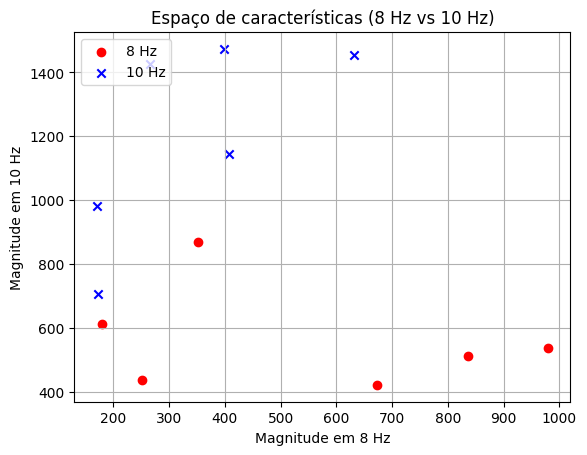

In [ ]:
fs = 250
def extract_features(signal):
    fft_vals = np.abs(np.fft.fft(signal))
    freqs = np.fft.fftfreq(len(signal), d=1/fs)

    idx_8 = np.argmin(np.abs(freqs - 8))
    idx_10 = np.argmin(np.abs(freqs - 10))

    return [fft_vals[idx_8], fft_vals[idx_10]]

X_feat = np.array([extract_features(x) for x in X])

plt.figure()
plt.scatter(X_feat[y == 1, 0],
            X_feat[y == 1, 1],
            color='red', marker='o', label='8 Hz')
plt.scatter(X_feat[y == -1, 0],
            X_feat[y == -1, 1],
            color='blue', marker='x', label='10 Hz')
plt.title('Espaço de características (8 Hz vs 10 Hz)')
plt.xlabel('Magnitude em 8 Hz')
plt.ylabel('Magnitude em 10 Hz')
plt.legend(loc='upper left')
plt.grid()

plt.show()


##Etapa 06
*Apresente a matriz de confusão.*


In [ ]:
TP = np.sum((y_test == 1) & (y_pred == 1))
TN = np.sum((y_test == -1) & (y_pred == -1))
FP = np.sum((y_test == -1) & (y_pred == 1))
FN = np.sum((y_test == 1) & (y_pred == -1))

matriz_confusao = np.array([[TP, FN],
                            [FP, TN]])

print("Matriz de Confusão:\n", matriz_confusao)

Matriz de Confusão:
 [[0 2]
 [0 2]]


##Etapa 07

*Plote uma das linhas da matriz de entrada para cada classe e sua respectiva magnitude da FFT. O que é possível observar no tempo e na frequência obtidos?*

A análise no tempo não é muito clara, já na frequência é possível observar picos de amplitude próximo às frequencias de estímulo e harmônicos. No artigo fala que o cérebro responde com 140ms de atraso, o que pode justificar a magnitude da FFT pouco deslocada de 8Hz e 10Hz.

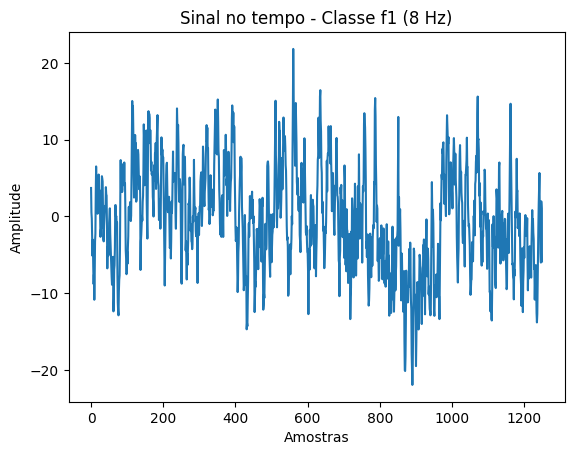

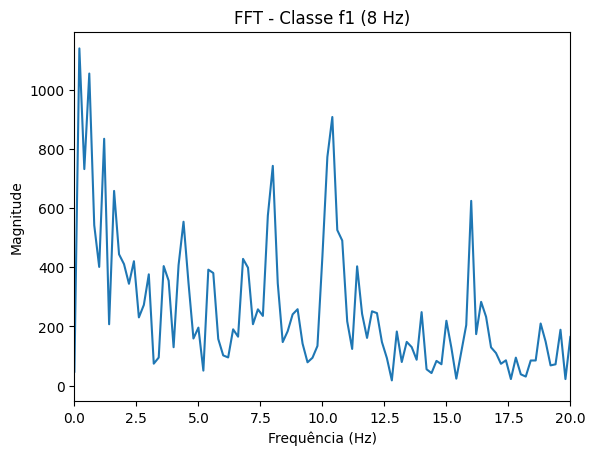

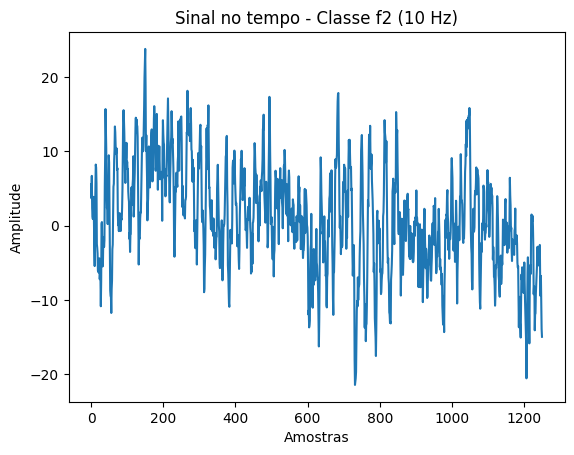

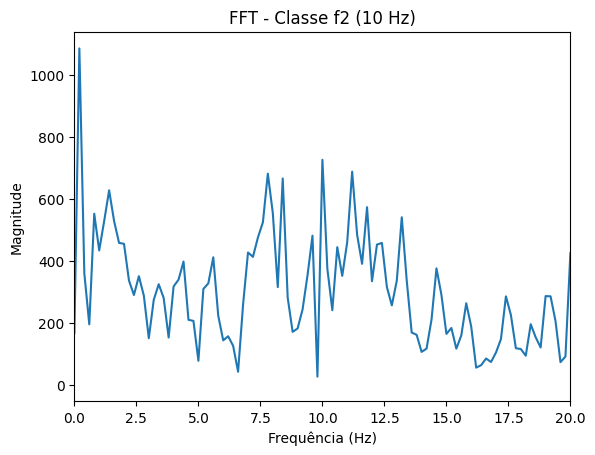

In [ ]:
fs = 250  # frequência de amostragem do artigo
trial_f1 = X[y == 1][0]
trial_f2 = X[y == -1][0]

#fft
def calcular_fft(trial):

    trial = trial - np.mean(trial) # remover componente cc
    window = np.hamming(len(trial))
    trial = trial * window

    fft = np.abs(np.fft.rfft(trial))
    freqs = np.fft.rfftfreq(len(trial), d=1/fs)

    return freqs, np.abs(fft)

freqs1, fft_f1 = calcular_fft(trial_f1)
freqs2, fft_f2 = calcular_fft(trial_f2)

#plot f1 - tempo
plt.figure()
plt.plot(trial_f1)
plt.title("Sinal no tempo - Classe f1 (8 Hz)")
plt.xlabel("Amostras")
plt.ylabel("Amplitude")
plt.show()

#plot f1 - frequencia
plt.figure()
plt.plot(freqs1, fft_f1)
plt.xlim(0, 20)
plt.title("FFT - Classe f1 (8 Hz)")
plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude")
plt.show()

#plot f2 - tempo
plt.figure()
plt.plot(trial_f2)
plt.title("Sinal no tempo - Classe f2 (10 Hz)")
plt.xlabel("Amostras")
plt.ylabel("Amplitude")
plt.show()

#plot f2 - frequencia

plt.figure()
plt.plot(freqs2, fft_f2)
plt.xlim(0, 20)
plt.title("FFT - Classe f2 (10 Hz)")
plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude")
plt.show()

##Etapa 08

*Proponha uma tecnica de extração de características, de modo que não seja necessário empregar todas as 1250 amostras do sinal realizadas em cada coleta, mas que seja possível reduzir a dimensão da matriz de dados X sem perder a informação relevante.*

A representação do sinal no domínio do tempo é ruidosa e difícil de categorizar para ser utilizada com o perceptron. A melhor forma de analisar esse dataset é utilizar a fft, que representa a energia liberada ao receber o estimulo. Uma solução aind amais simples é fazer correlação do sinal com senos, que será apresentada abaixo:



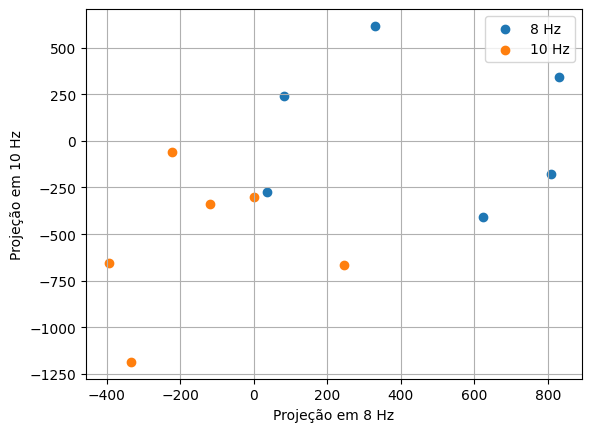

In [ ]:
fs = 250
t = np.arange(X.shape[1]) / fs

seno_8 = np.sin(2 * np.pi * 8 * t)
seno_10 = np.sin(2 * np.pi * 10 * t)

X_feat = []

for trial in X:
    feat_8 = np.dot(trial, seno_8)
    feat_10 = np.dot(trial, seno_10)
    X_feat.append([feat_8, feat_10])

X_feat = np.array(X_feat, dtype=np.float32)

X_f1 = X_feat[y == 1]
X_f2 = X_feat[y == -1]

W = np.random.rand(3)

activation = lambda x: -1 if x < 0 else 1

learning_rate = 0.01
training_steps = 1000

plt.scatter(X_feat[y == 1, 0], X_feat[y == 1, 1], label='8 Hz')
plt.scatter(X_feat[y == -1, 0], X_feat[y == -1, 1], label='10 Hz')
plt.xlabel('Projeção em 8 Hz')
plt.ylabel('Projeção em 10 Hz')
plt.legend()
plt.grid()
plt.show()



Aqui fica mais claro que o problema é lienarmente separável.

##Desafio

 *Implementar o perceptron com a estratégia proposta no item 8 do roteiro. Comparar com o desempenho do perceptron anterior. Comentar.*

In [ ]:
#treinamento
for i in range(training_steps):
    for j in range(len(X_train)):
        x_i = X_train[j]
        y_true = y_train[j]

        u = np.dot(W, x_i)
        y_pred = activation(u)

        if y_pred != y_true:
            W += learning_rate * y_true * x_i

# Validação
y_test_pred = []

for x in X_test:
    u = np.dot(W, x)
    y_test_pred.append(activation(u))

y_test_pred = np.array(y_test_pred)

acc_test = np.mean(y_test_pred == y_test) * 100

print("\nPredições no teste:")
for i in range(len(X_test)):
    print(f"Predito: {y_test_pred[i]} - Real: {y_test[i]}")

print("\nAcurácia no teste: %.2f%%" % acc_test)

#Matriz de confusão
TP = np.sum((y_test == 1) & (y_test_pred == 1))
TN = np.sum((y_test == -1) & (y_test_pred == -1))
FP = np.sum((y_test == -1) & (y_test_pred == 1))
FN = np.sum((y_test == 1) & (y_test_pred == -1))

matriz_confusao = np.array([[TP, FP],
                            [FN, TN]])

print("\nMatriz de Confusão:\n", matriz_confusao)


Predições no teste:
Predito: 1 - Real: 1
Predito: 1 - Real: 1
Predito: -1 - Real: -1
Predito: -1 - Real: -1

Acurácia no teste: 100.00%

Matriz de Confusão:
 [[2 0]
 [0 2]]


Matriz de confusão coerente com a análise do problema e soluções do modelo.